In [33]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import joblib
print("All libraries imported successfully.")

All libraries imported successfully.


In [34]:
# Load dataset

df = pd.read_csv("../data/faircredit_sa_dataset_verified.csv")

df.head()

,monthly_gross_income,statutory_deductions,monthly_net_income,declared_living_expenses,minimum_expense_norm,living_expenses_used,existing_debt_repayments,maintenance_obligations,discretionary_income_before_new_credit,requested_credit_amount,...,arrears_amount,defaults_history,employment_months,income_variability_pct,savings_amount,credit_utilisation_pct,affordability_pass,synthetic_risk_probability,faircredit_readiness_score,credit_risk
0,43088.02,3944.10,39143.92,21497.05,4338.60,21497.05,4189.38,2694.83,10762.66,98541.60,...,0.0,0,47,15.2,7064.12,43.4,1,0.4759,52,0
1,6026.02,146.49,5879.53,3130.88,1152.76,3130.88,414.44,390.20,1944.01,11895.62,...,0.0,0,46,10.5,857.87,32.5,1,0.4195,58,0
2,29165.32,1798.91,27366.41,7990.87,3196.94,7990.87,2231.99,0.00,17143.55,86332.74,...,0.0,0,10,19.2,14955.68,28.6,1,0.5557,44,1
3,16531.76,1186.74,15345.02,8225.40,2093.24,8225.40,3408.19,0.00,3711.43,6625.32,...,0.0,0,49,13.6,46388.53,74.8,1,0.3522,65,1
4,3938.77,101.58,3837.19,558.07,1011.87,1011.87,571.90,0.00,2253.42,11584.09,...,0.0,0,49,8.8,989.37,60.3,1,0.5758,42,0


In [35]:
# Check the dimensions of the dataset before any modelling changes are made.

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 10000
Columns: 26


In [36]:
# Create financially meaningful ratios.
# Raw monetary values are useful, but ratios often describe a consumer's
# financial position more clearly. For example, a R2,000 monthly debt
# repayment has very different implications for someone earning R5,000
# compared with someone earning R50,000.

df["debt_to_income_ratio"] = (
    df["existing_debt_repayments"] /
    df["monthly_net_income"].clip(lower=1)
)

df["requested_credit_to_income_ratio"] = (
    df["requested_credit_amount"] /
    (df["monthly_gross_income"].clip(lower=1) * 12)
)

df["installment_to_income_ratio"] = (
    df["proposed_installment"] /
    df["monthly_net_income"].clip(lower=1)
)

df["expense_to_income_ratio"] = (
    df["living_expenses_used"] /
    df["monthly_net_income"].clip(lower=1)
)

df["savings_to_income_ratio"] = (
    df["savings_amount"] /
    df["monthly_net_income"].clip(lower=1)
)

df["arrears_to_income_ratio"] = (
    df["arrears_amount"] /
    df["monthly_net_income"].clip(lower=1)
)

In [37]:
# Inspect the newly created ratios to make sure they were calculated correctly.

ratio_columns = [
    "debt_to_income_ratio",
    "requested_credit_to_income_ratio",
    "installment_to_income_ratio",
    "expense_to_income_ratio",
    "savings_to_income_ratio",
    "arrears_to_income_ratio"
]

df[ratio_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
debt_to_income_ratio,10000.0,0.142023,0.070168,0.000000,0.093315,0.133720,0.180838,0.508553
requested_credit_to_income_ratio,10000.0,0.132622,0.064649,0.020875,0.076620,0.130031,0.187486,0.249916
installment_to_income_ratio,10000.0,0.098897,0.079717,0.006291,0.046674,0.078837,0.124555,0.584199
expense_to_income_ratio,10000.0,0.406260,0.113390,0.153394,0.318427,0.401514,0.484493,1.339475
savings_to_income_ratio,10000.0,0.792546,1.115047,0.016515,0.263884,0.491958,0.946519,49.538681
arrears_to_income_ratio,10000.0,0.041667,0.139033,0.000000,0.000000,0.000000,0.000000,0.849198


In [38]:
# Select the features that would realistically be available when assessing a new consumer.
features = [
    "monthly_gross_income",
    "statutory_deductions",
    "monthly_net_income",
    "living_expenses_used",
    "existing_debt_repayments",
    "maintenance_obligations",
    "requested_credit_amount",
    "loan_term_months",
    "proposed_installment",
    "number_existing_credit_accounts",
    "missed_payments_12m",
    "arrears_amount",
    "defaults_history",
    "employment_months",
    "income_variability_pct",
    "savings_amount",
    "credit_utilisation_pct",

    # Engineered financial ratios
    "debt_to_income_ratio",
    "requested_credit_to_income_ratio",
    "installment_to_income_ratio",
    "expense_to_income_ratio",
    "savings_to_income_ratio",
    "arrears_to_income_ratio"
]

target = "credit_risk"

X = df[features]
y = df[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (10000, 23)
Target shape: (10000,)


In [39]:
# Confirm that the target distribution remains reasonably balanced.

print(y.value_counts())

print("\nPercentage distribution:")
print((y.value_counts(normalize=True) * 100).round(2))

credit_risk
0    5757
1    4243
Name: count, dtype: int64

Percentage distribution:
credit_risk
0    57.57
1    42.43
Name: proportion, dtype: float64


In [40]:
# Split the dataset into training and testing sets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

print("\nTraining target distribution:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting target distribution:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training rows: 8000
Testing rows: 2000

Training target distribution:
credit_risk
0    57.58
1    42.42
Name: proportion, dtype: float64

Testing target distribution:
credit_risk
0    57.55
1    42.45
Name: proportion, dtype: float64


In [41]:
# Logistic Regression is used as the baseline model because it is interpretable
# and provides a strong benchmark for deciding whether a more complex model
# actually improves predictive performance.

logistic_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['monthly_gross_income','statutory_deductions','monthly_net_income',..., 'expense_to_income_ratio','savings_to_income_ratio', 'arrears_to_income_ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [42]:
# Generate both class predictions and probabilities.

y_pred_log = logistic_model.predict(X_test)
y_prob_log = logistic_model.predict_proba(X_test)[:, 1]

In [43]:
# Evaluate the Logistic Regression baseline.

print("Logistic Regression")
print("-" * 40)

print(f"Accuracy:  {accuracy_score(y_test, y_pred_log):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_log):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_log):.3f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_log):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_log):.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression
----------------------------------------
Accuracy:  0.676
Precision: 0.649
Recall:    0.519
F1 Score:  0.577
ROC-AUC:   0.726

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.79      0.74      1151
           1       0.65      0.52      0.58       849

    accuracy                           0.68      2000
   macro avg       0.67      0.66      0.66      2000
weighted avg       0.67      0.68      0.67      2000



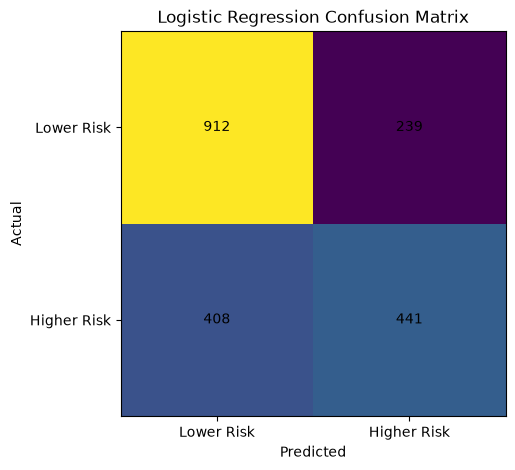

In [44]:
# Display the Logistic Regression confusion matrix.
cm_log = confusion_matrix(y_test, y_pred_log)

fig, ax = plt.subplots(figsize=(6, 5))

ax.imshow(cm_log)

ax.set_title("Logistic Regression Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Lower Risk", "Higher Risk"])

ax.set_yticks([0, 1])
ax.set_yticklabels(["Lower Risk", "Higher Risk"])

for i in range(cm_log.shape[0]):
    for j in range(cm_log.shape[1]):
        ax.text(
            j,
            i,
            cm_log[i, j],
            ha="center",
            va="center"
        )

plt.show()

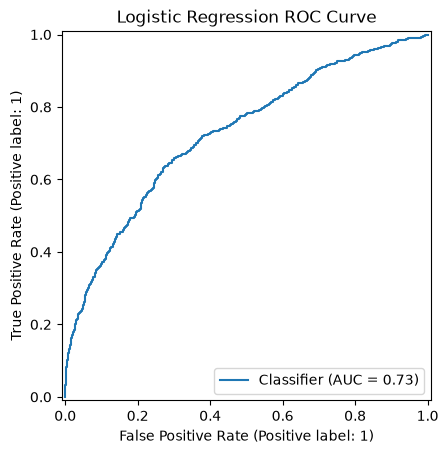

In [45]:
# Plot the Receiver Operating Characteristic curve.

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_log
)

plt.title("Logistic Regression ROC Curve")
plt.show()

In [46]:
# Train a Random Forest as a non-linear comparison model.
# Random Forest can capture relationships that Logistic Regression may miss,

rf_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [47]:
# Generate Random Forest class predictions and probabilities.

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [48]:
# Evaluate the Random Forest model using the same metrics as the baseline.

print("Random Forest")
print("-" * 40)

print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.3f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_rf):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_rf):.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest
----------------------------------------
Accuracy:  0.663
Precision: 0.626
Recall:    0.514
F1 Score:  0.564
ROC-AUC:   0.708

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.77      0.73      1151
           1       0.63      0.51      0.56       849

    accuracy                           0.66      2000
   macro avg       0.65      0.64      0.64      2000
weighted avg       0.66      0.66      0.66      2000



In [49]:
# Compare both models side by side.
# ROC-AUC is particularly important for FairCredit because the application
# will use predicted risk probabilities rather than only a hard 0/1 decision.

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.6765,0.648529,0.519435,0.576848,0.726295
1,Random Forest,0.6630,0.625538,0.513545,0.564036,0.708401


In [50]:
# Examine Random Forest feature importance.


feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
16,credit_utilisation_pct,0.106738
17,debt_to_income_ratio,0.085630
20,expense_to_income_ratio,0.057576
19,installment_to_income_ratio,0.056419
18,requested_credit_to_income_ratio,0.052180
21,savings_to_income_ratio,0.051624
15,savings_amount,0.051490
4,existing_debt_repayments,0.050994
14,income_variability_pct,0.050642
8,proposed_installment,0.049425


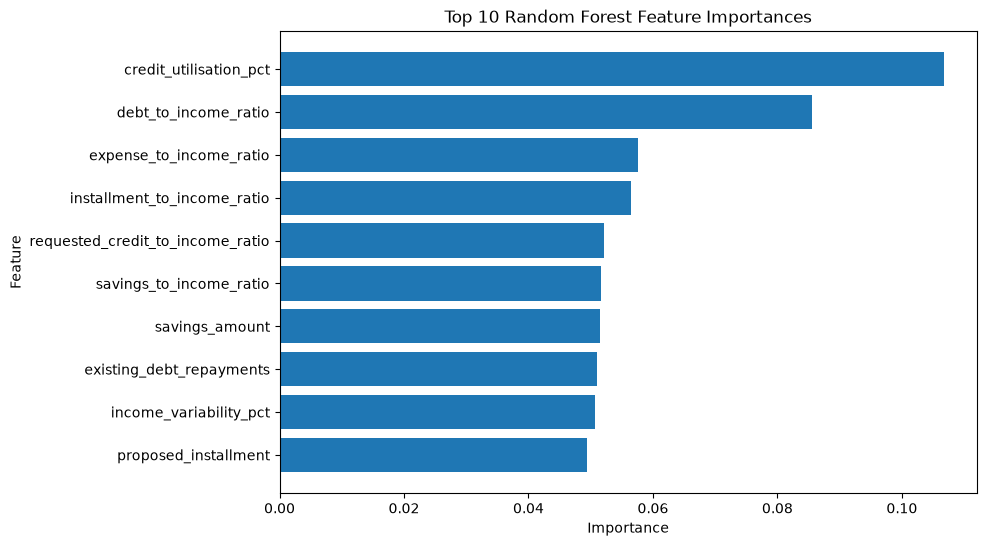

In [51]:
# Visualise the ten most important Random Forest features.

top_features = (
    feature_importance
    .head(10)
    .sort_values("Importance")
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [52]:
# Evaluate several classification thresholds for Logistic Regression.


thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

threshold_results = []

for threshold in thresholds:
    predictions = (y_prob_log >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.30,0.5835,0.505747,0.829211,0.628291
1,0.35,0.6285,0.544992,0.756184,0.633448
2,0.40,0.6650,0.589769,0.692580,0.637053
3,0.45,0.6860,0.634265,0.614841,0.624402
4,0.50,0.6765,0.648529,0.519435,0.576848
5,0.55,0.6805,0.697368,0.436985,0.537292
6,0.60,0.6730,0.734940,0.359246,0.482595


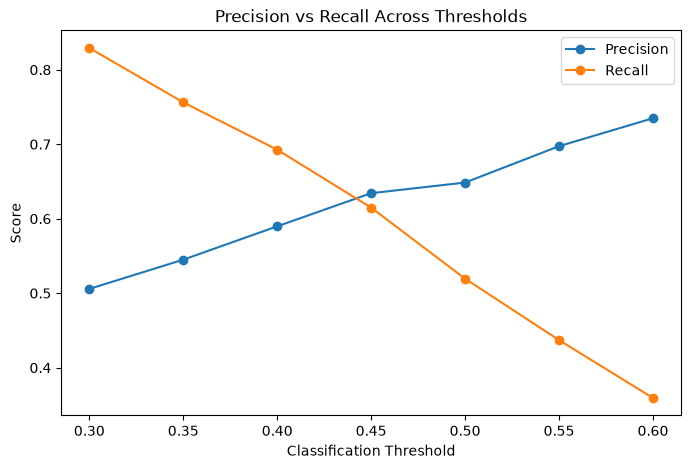

In [53]:
# Plot precision and recall across different probability thresholds.

plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall Across Thresholds")

plt.legend()
plt.show()

In [54]:
# Save the selected model for later use in the FairCredit application.


selected_model = logistic_model

joblib.dump(
    selected_model,
    "../models/faircredit_risk_model.pkl"
)

print("FairCredit risk model saved successfully.")

FairCredit risk model saved successfully.


In [55]:
# Save the model feature names so the application can reproduce the exact
# The reduced Logistic Regression model is selected as the final FairCredit
# risk model because it achieves almost the same ROC-AUC as the full model
# while using fewer redundant features.
#
# A simpler model is preferable here because FairCredit is an explainable
# consumer-facing system, so interpretability matters.

final_model = reduced_logistic_model
final_features = reduced_features

joblib.dump(
    final_model,
    "../models/faircredit_risk_model.pkl"
)

joblib.dump(
    final_features,
    "../models/faircredit_model_features.pkl"
)

print("Final FairCredit risk model saved successfully.")
print(f"Number of model features: {len(final_features)}")

Final FairCredit risk model saved successfully.
Number of model features: 17


In [56]:
# Examine correlations between modelling features to identify variables
# that contain very similar information.
# Strong correlations are particularly important for Logistic Regression because highly related predictors can make individual coefficients less
# stable and explanations harder to interpret.

correlation_matrix = X.corr()

high_correlations = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        correlation = correlation_matrix.iloc[i, j]

        if abs(correlation) >= 0.80:
            high_correlations.append({
                "Feature 1": correlation_matrix.columns[i],
                "Feature 2": correlation_matrix.columns[j],
                "Correlation": correlation
            })

high_correlation_df = pd.DataFrame(high_correlations)

high_correlation_df.sort_values(
    "Correlation",
    key=abs,
    ascending=False
)

,Feature 1,Feature 2,Correlation
1,monthly_net_income,monthly_gross_income,0.997691
0,statutory_deductions,monthly_gross_income,0.947059
3,living_expenses_used,monthly_gross_income,0.942336
5,living_expenses_used,monthly_net_income,0.940604
2,monthly_net_income,statutory_deductions,0.923067
7,existing_debt_repayments,statutory_deductions,0.897629
6,existing_debt_repayments,monthly_gross_income,0.895546
4,living_expenses_used,statutory_deductions,0.890346
8,existing_debt_repayments,monthly_net_income,0.883008
9,existing_debt_repayments,living_expenses_used,0.845632


In [57]:
# Logistic Regression coefficients show the direction in which each standardised feature influences the model.

# Positive coefficients push predictions toward higher estimated risk,
# while negative coefficients push predictions toward lower estimated risk.
# These relationships describe the synthetic model only and must not be interpreted as causal effects on real South African consumers.

trained_logistic = logistic_model.named_steps["model"]

coefficient_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": trained_logistic.coef_[0]
})

coefficient_df["Absolute Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)

coefficient_df.sort_values(
    "Absolute Coefficient",
    ascending=False
)

,Feature,Coefficient,Absolute Coefficient
16,credit_utilisation_pct,0.362315,0.362315
17,debt_to_income_ratio,0.345144,0.345144
10,missed_payments_12m,0.280931,0.280931
12,defaults_history,0.181119,0.181119
20,expense_to_income_ratio,0.175025,0.175025
8,proposed_installment,0.135904,0.135904
19,installment_to_income_ratio,0.131545,0.131545
2,monthly_net_income,-0.127612,0.127612
1,statutory_deductions,0.124339,0.124339
21,savings_to_income_ratio,-0.118012,0.118012


In [58]:
# Build a reduced feature set that prioritises financially interpretable variables while removing some redundant predictors.
# The objective is to determine whether a simpler model can retain similar
# predictive performance while producing clearer explanations.

reduced_features = [
    "monthly_net_income",
    "living_expenses_used",
    "maintenance_obligations",

    "requested_credit_amount",
    "loan_term_months",

    "number_existing_credit_accounts",
    "missed_payments_12m",
    "arrears_amount",
    "defaults_history",

    "employment_months",
    "income_variability_pct",
    "savings_amount",
    "credit_utilisation_pct",

    "debt_to_income_ratio",
    "requested_credit_to_income_ratio",
    "installment_to_income_ratio",
    "expense_to_income_ratio"
]

X_reduced = df[reduced_features]

print("Original number of features:", len(features))
print("Reduced number of features:", len(reduced_features))

Original number of features: 23
Reduced number of features: 17


In [59]:
# Create a new train/test split for the reduced feature set using the
# same random state and stratification as the original experiment.

X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = (
    train_test_split(
        X_reduced,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )
)

In [60]:
# Train a simplified Logistic Regression model using the reduced
# feature set.

reduced_logistic_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

reduced_logistic_model.fit(
    X_train_reduced,
    y_train_reduced
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['monthly_net_income','living_expenses_used','maintenance_obligations',..., 'requested_credit_to_income_ratio','installment_to_income_ratio', 'expense_to_income_ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [61]:
# Evaluate whether reducing feature redundancy materially affects
# predictive performance.

y_pred_reduced = reduced_logistic_model.predict(
    X_test_reduced
)

y_prob_reduced = reduced_logistic_model.predict_proba(
    X_test_reduced
)[:, 1]

print("Reduced Logistic Regression")
print("-" * 40)

print(
    f"Accuracy:  "
    f"{accuracy_score(y_test_reduced, y_pred_reduced):.3f}"
)

print(
    f"Precision: "
    f"{precision_score(y_test_reduced, y_pred_reduced):.3f}"
)

print(
    f"Recall:    "
    f"{recall_score(y_test_reduced, y_pred_reduced):.3f}"
)

print(
    f"F1 Score:  "
    f"{f1_score(y_test_reduced, y_pred_reduced):.3f}"
)

print(
    f"ROC-AUC:   "
    f"{roc_auc_score(y_test_reduced, y_prob_reduced):.3f}"
)

Reduced Logistic Regression
----------------------------------------
Accuracy:  0.671
Precision: 0.644
Recall:    0.506
F1 Score:  0.567
ROC-AUC:   0.726


In [62]:
# Compare the full and reduced Logistic Regression models.
# If performance remains similar, the reduced model is preferable because
# fewer redundant features make FairCredit easier to explain and maintain.

comparison = pd.DataFrame({
    "Model": [
        "Full Logistic Regression (23 features)",
        "Reduced Logistic Regression (17 features)"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test_reduced, y_pred_reduced)
    ],

    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test_reduced, y_pred_reduced)
    ],

    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test_reduced, y_pred_reduced)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test_reduced, y_pred_reduced)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test_reduced, y_prob_reduced)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Full Logistic Regression (23 features),0.6765,0.648529,0.519435,0.576848,0.726295
1,Reduced Logistic Regression (17 features),0.6715,0.643713,0.506478,0.566908,0.725758
